Problem statement:
You have the dataset of diabetes patient. objective is to develop a classification model that accurately predicts is the patient diabetic or not using historical data.

Also predict the output for the new patient

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('/content/sample_data/diabetes.csv')

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   Pedigree       768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
Pedigree,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [7]:
df.shape

(768, 9)

with the above method, we understand that it is impossible for the columns - Glucose, Bloodpressure, Skinthickness, insulin, BMI to have 0 value.

To handle this, we follow:

Step 1: Replace these 0 value with NaN so that the pandas will treat them as missing

Step 2: Impute them with mean/median

In [9]:
cols_zero_invalid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [10]:
df[cols_zero_invalid] = df[cols_zero_invalid].replace(0, np.nan)

In [12]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
Pedigree,0
Age,0
Outcome,0


In [13]:
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].median())
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].median())
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].median())
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].median())
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())

In [15]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
Pedigree,0
Age,0
Outcome,0


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.0000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.0000,127.25000,846.00
BMI,768.0,32.457464,6.875151,18.200,27.50000,32.4000,36.60000,67.10
Pedigree,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
## Outlier detection

def cap_outlier(series):
  Q1 = series.quantile(0.25)
  Q3 = series.quantile(0.75)
  IQR = Q3 - Q1

  UB = Q3 + (1.5 * IQR)
  LB = Q1 - (1.5 * IQR)

  return series.clip(LB, UB)

In [21]:
for col in df:
  df[col] = cap_outlier(df[col])

print('Outliers capped')
df.describe().T

Outliers capped


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.837240,3.344157,0.000,1.00000,3.0000,6.00000,13.500
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.000
BloodPressure,768.0,72.358073,11.697097,40.000,64.00000,72.0000,80.00000,104.000
SkinThickness,768.0,28.866536,7.442353,14.500,25.00000,29.0000,32.00000,42.500
Insulin,768.0,124.691081,7.913595,112.875,121.50000,125.0000,127.25000,135.875
BMI,768.0,32.395615,6.667466,18.200,27.50000,32.4000,36.60000,50.250
Pedigree,768.0,0.458914,0.285596,0.078,0.24375,0.3725,0.62625,1.200
Age,768.0,33.199870,11.628404,21.000,24.00000,29.0000,41.00000,66.500
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.000


In [22]:
## ML model building

X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [23]:
## Feature scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
X_scaled

array([[ 0.64714967,  0.86604475, -0.03063207, ...,  0.18075386,
         0.58892732,  1.44569096],
       [-0.84896998, -1.20506583, -0.54391414, ..., -0.86980448,
        -0.37810147, -0.189304  ],
       [ 1.24559754,  2.01666174, -0.71500816, ..., -1.36506769,
         0.74659506, -0.10325164],
       ...,
       [ 0.34792574, -0.02157407, -0.03063207, ..., -0.92983638,
        -0.74949659, -0.27535637],
       [-0.84896998,  0.14279979, -1.05719621, ..., -0.34452531,
        -0.38510892,  1.18753386],
       [-0.84896998, -0.94206766, -0.20172609, ..., -0.29950138,
        -0.50423566, -0.87772293]])

In [25]:
## Split the dataset

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

In [26]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 8), (154, 8), (614,), (154,))

In [27]:
## Train the baseline model then further we will find the optimal value of K

knn = KNeighborsClassifier(n_neighbors=17)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=17)

In [28]:
y_pred = knn.predict(X_test)

In [29]:
acc = accuracy_score(y_test, y_pred)
acc

0.7987012987012987

In [30]:
## Optimal value of K

## we will plot the graph of error rate vs different K values

error_rate = []
for i in range(3, 20):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train, y_train)
  y_pred = knn.predict(X_test)
  error_rate.append(np.mean(y_pred != y_test))

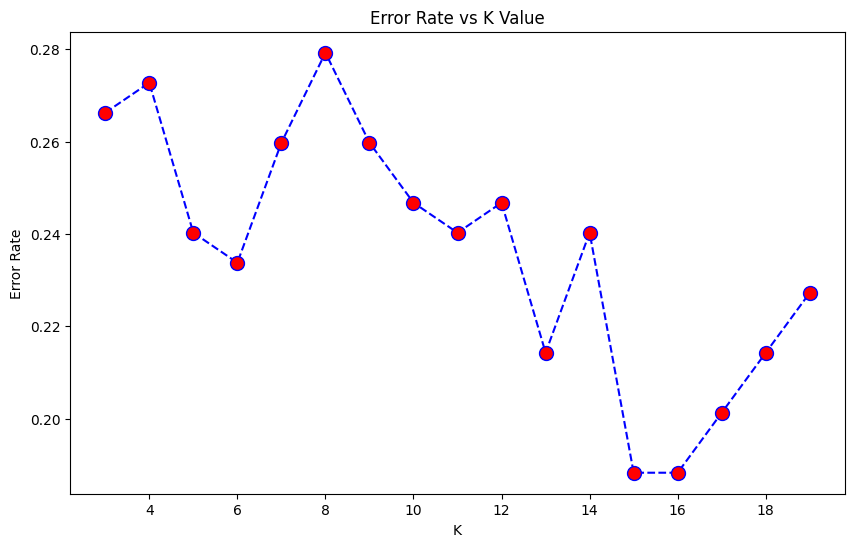

In [31]:
## Print the values of K vs error rate

plt.figure(figsize=(10, 6))
plt.plot(range(3, 20), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

In [32]:
## prediction for new patient

new_patient = {
    'Pregnencies' : 6,
    'Glucose' : 148,
    'BloodPressure' : 72,
    'SkinThickness' : 35,
    'Insulin' : 0,
    'BMI' : 33.6,
    'DiabetesPedigreeFunction' : 0.627,
    'Age' : 50
}

In [33]:
new_df = pd.DataFrame(new_patient, index=[0])
new_df

,Pregnencies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50


In [34]:
knn.predict(new_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


array([1])

In [35]:
if knn.predict(new_df) == 1:
  print("Patient is Diabetic")
else:
  print("Patient is not Diabetic")

Patient is Diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
